# Task 1: Import Libraries

In [1]:
from datasets import load_dataset

from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import ViTImageProcessor
from torchvision.transforms import (RandomVerticalFlip, CenterCrop, Compose, Normalize, RandomHorizontalFlip, RandomResizedCrop, Resize, ToTensor)

from transformers import ViTForImageClassification
from transformers import TrainingArguments, Trainer

from sklearn.metrics import f1_score, confusion_matrix
import numpy as np
import torch

ModuleNotFoundError: No module named 'datasets'

# Task 2: Load the Dataset

In [ ]:
train_validation_ds = load_dataset("/usercode/mnist_dataset/", split='train[:500]')
test_ds = load_dataset("/usercode/mnist_dataset/", split='test[:10]')

train_validation_splits = train_validation_ds.train_test_split(test_size=0.1)

train_ds, validation_ds = train_validation_splits['train'], train_validation_splits['test']

# Task 3: Visualize the Dataset

In [ ]:
train_ds[0]["image"]

<BarContainer object of 10 artists>

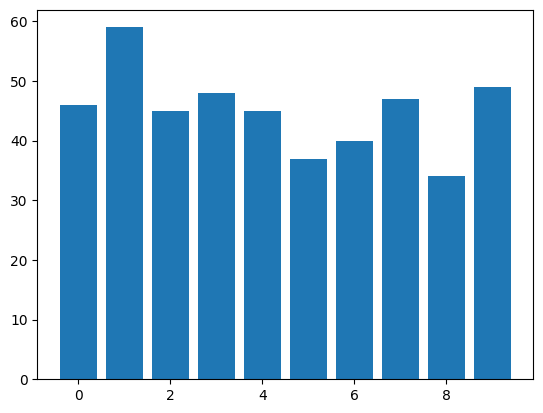

In [ ]:
train_labels = Counter([point['label'] for point in train_ds])
plt.clf()
plt.bar(train_labels.keys(), train_labels.values())

# Task 4: Create a Mapping of Class Names to Index

In [ ]:
def get_label_id_maps(dataset):
    label_names = dataset.features.get('label').names
    id2label = {id: label for id, label in enumerate(label_names)}
    label2id = {label: id for id, label in id2label.items()}
    return id2label, label2id

id2label, label2id = get_label_id_maps(train_ds)

num_labels = len(id2label)

# Task 5: Load the Preprocessor for the Dataset

In [ ]:
PRETRAINED_MODEL_NAME = 'google/vit-base-patch16-224-in21k'
processor = ViTImageProcessor.from_pretrained(PRETRAINED_MODEL_NAME)

# Task 6: Define Data Augmentations

In [ ]:
image_mean, image_std = processor.image_mean, processor.image_std
size = processor.size["height"],processor.size["width"]

normalize = Normalize(mean=image_mean, std=image_std)
_train_transforms = Compose(
        [
            RandomHorizontalFlip(p=0.2),
            RandomVerticalFlip(p=0.1),
            RandomResizedCrop(size),
            ToTensor(),
            normalize,
        ]
    )

_validation_transforms = Compose(
        [
            Resize(size),
            ToTensor(),
            normalize,
        ]
    )

# Task 7:  Implement Data Transformation

In [ ]:
def train_transforms(batch):
    rgb_images = [image.convert("RGB") for image in batch['image']]
    batch['pixel_values'] = [_train_transforms(image) for image in rgb_images]
    return batch

def validation_transforms(batch):
    rgb_images = [image.convert("RGB") for image in batch['image']]
    batch['pixel_values'] = [_validation_transforms(image) for image in rgb_images]
    return batch

train_ds.set_transform(train_transforms)
validation_ds.set_transform(validation_transforms)
test_ds.set_transform(validation_transforms)

# Task 8: Collate the Function for DataLoader

In [ ]:
def collate_fn(batch):
    pixel_values = torch.stack([example["pixel_values"] for example in batch])
    labels = torch.tensor([example["label"] for example in batch])
    return {"pixel_values": pixel_values, "labels": labels}

# Task 9: Create a Model

In [ ]:
model = ViTForImageClassification.from_pretrained(
     PRETRAINED_MODEL_NAME,
     num_labels=num_labels,
     id2label=id2label,
     label2id=label2id
     )

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# Task 10: Define a Metric for the Model

In [ ]:
def evaluate(pred_labels):
    predictions, labels = pred_labels.predictions, pred_labels.label_ids
    predictions = np.argmax(predictions, axis=1)
    return {"f1": f1_score(predictions, labels, average='micro')}

# Task 11: Set Up Trainer Arguments

In [ ]:
METRIC_NAME = "f1"

args = TrainingArguments(
    output_dir="mnist-model-output",
    save_strategy="epoch",
    evaluation_strategy="epoch",
    per_device_train_batch_size=20,
    per_device_eval_batch_size=16,
    logging_steps= 100,
    learning_rate=1e-5,
    num_train_epochs=1,
    weight_decay=0.01,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model=METRIC_NAME,
    logging_dir='logs',
    remove_unused_columns=False,
)

# Task 12: Create a Trainer Object

In [ ]:
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=validation_ds,
    data_collator=collate_fn,
    compute_metrics=evaluate,
    tokenizer=processor,
)

# Task 13: Evaluate the Model Before Training

In [ ]:
outputs_before_training = trainer.predict(validation_ds)
print(outputs_before_training.metrics)

{'test_loss': 2.2986299991607666, 'test_f1': 0.18, 'test_runtime': 34.3881, 'test_samples_per_second': 1.454, 'test_steps_per_second': 0.116}


# Task 14: Train the Model

In [ ]:
train_results = trainer.train()

Epoch,Training Loss,Validation Loss


# Task 15: Visualize the Performance in TensorBoard

In [ ]:
%load_ext tensorboard
%tensorboard --logdir=/logs --host 0.0.0.0 --port 3000

# Task 16: Evaluate the Model

In [ ]:
trained_model = ViTForImageClassification.from_pretrained(
     "./usercode/trained_model"
 )
trainer.model = trained_model
outputs_after_training = trainer.predict(validation_ds)
print(outputs_after_training.metrics)

# Task 17: Set Up the Confusion Matrix

In [ ]:
y_true = outputs_after_training.label_ids
y_pred = outputs_after_training.predictions.argmax(axis=1)

model_confusion_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(model_confusion_matrix, annot=True)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

# Task 18: Save the Model and Metrics

In [ ]:
trainer.save_model()
trainer.save_metrics("evaluation", outputs_after_training.metrics)
trainer.save_state()

# Task 19: Set Up an Inference for the Model

In [ ]:
def show_results(test_image, prediction):
    plt.figure()
    plt.xticks([], [])
    plt.yticks([], [])
    plt.imshow(test_image)
    plt.xlabel(f'Predicted Digit Label: {prediction}')
    plt.show()

test_image = test_ds[0]["image"].convert("RGB")
inputs = processor(images=test_image, return_tensors="pt")
pixel_values = inputs.pixel_values
test_logits = trained_model(pixel_values).logits
prediction_id = test_logits.argmax(-1).item()
prediction_label = id2label[prediction_id]
show_results(test_image, prediction_label)